In [1]:
# Parámetros a configurar:

experiment_name = "command2"
task_name = "Command2"
cfg_dir = "C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/aerotaxi/env_command/env_6/grid_hiperparametros/cfg_files"
path_resultados = "C:/Users/Teresa/Documents/GitHub/navsim/tmp/tmpTeresa/resultados_grid_command_v2"
isaaclab_bat = "C:/Users/Teresa/Desktop/RuralData/IsaacLab/IsaacLab/isaaclab.bat"
train_script = "C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/rl_v5_1_0/rsl_rl/train.py"
id_task = f"Isaac-{task_name}-Aerotaxi-RANDOM" # luego se le añade el número de task con el guión (Isaac-Command2-Aerotaxi-RANDOM-34)
play_script = "C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/rl_v5_1_0/rsl_rl/play.py"

In [2]:
import random
import os

# Si los directorios no existen (el último indicado), lo crea
os.makedirs(cfg_dir, exist_ok=True)
os.makedirs(path_resultados, exist_ok=True)
# Opciones de hiperparámetros
param_options = {
    "init_noise_std": [0.0, 0.1, 0.2, 0.5, 1.0],
    "actor_hidden_dims": [[64, 64], [128, 128], [256, 256], [128, 64]],
    "critic_hidden_dims": [[64, 64], [128, 128], [256, 256]],
    "activation": ["relu", "tanh", "elu", "gelu"],
    "value_loss_coef": [0.5, 1.0, 2.0],
    "clip_param": [0.1, 0.2, 0.3],
    "entropy_coef": [0.0, 0.001, 0.01, 0.05],
    "num_learning_epochs": [4, 8, 12],
    "num_mini_batches": [2, 4, 8],
    "learning_rate": [1e-4, 3e-4, 1e-3, 3e-3],
    "gamma": [0.95, 0.98, 0.99],
    "lam": [0.90, 0.95, 0.97],
    "max_grad_norm": [0.5, 1.0, 2.0],
    "desired_kl": [0.005, 0.01, 0.02],
}

num_trials = 35  # cantidad de configuraciones

cfg_files = []

for i in range(num_trials):
    run_name = f"ppo_random_{experiment_name}_{i+1}"
    sampled = {k: random.choice(v) for k, v in param_options.items()}

    # Convertir listas a string
    actor_dims = sampled["actor_hidden_dims"]
    critic_dims = sampled["critic_hidden_dims"]

    cfg_content = f"""
from isaaclab.utils import configclass
from isaaclab_rl.rsl_rl import RslRlOnPolicyRunnerCfg, RslRlPpoActorCriticCfg, RslRlPpoAlgorithmCfg

@configclass
class {task_name}PPORunnerCfg(RslRlOnPolicyRunnerCfg):
    num_steps_per_env = 24
    max_iterations = 2001
    save_interval = 100
    experiment_name = "{experiment_name}"
    run_name = "{run_name}"
    resume = False
    empirical_normalization = False
    csv_path_metrics = "{path_resultados}"
    callbacks = True
    policy = RslRlPpoActorCriticCfg(
        init_noise_std={sampled['init_noise_std']},
        actor_hidden_dims={actor_dims},
        critic_hidden_dims={critic_dims},
        activation="{sampled['activation']}",
    )
    algorithm = RslRlPpoAlgorithmCfg(
        value_loss_coef={sampled['value_loss_coef']},
        use_clipped_value_loss=True,
        clip_param={sampled['clip_param']},
        entropy_coef={sampled['entropy_coef']},
        num_learning_epochs={sampled['num_learning_epochs']},
        num_mini_batches={sampled['num_mini_batches']},
        learning_rate={sampled['learning_rate']},
        schedule="adaptive",
        gamma={sampled['gamma']},
        lam={sampled['lam']},
        desired_kl={sampled['desired_kl']},
        max_grad_norm={sampled['max_grad_norm']},
    )
"""
    cfg_path = os.path.join(cfg_dir, f"{run_name}_cfg.py")
    with open(cfg_path, "w") as f:
        f.write(cfg_content.strip())
    cfg_files.append((run_name, cfg_path))

# Crear archivo PowerShell para ejecutar todas las configuraciones
powershell_script = os.path.join(cfg_dir, "run_all.ps1")

num_envs =  [64, 128, 512, 1024, 2048, 4096, 8196] #número de entornos para train (paralelizados)

with open(powershell_script, "w") as f:
    f.write("$ErrorActionPreference = 'Stop'\n\n")
    j = 0
    for run_name, cfg_path in cfg_files:
        # Convertir path a módulo Python (reemplazar / y .py)
        num_envs_i = random.choice(num_envs)
        module_path = cfg_path.replace("/", ".").replace("\\", ".").replace(".py", "")
        f.write(f'Write-Host "Ejecutando {run_name}"\n')
        f.write(f'& "{isaaclab_bat}" -p "{train_script}" --task {id_task}-{j+1} --num_envs {num_envs_i} --headless \n\n')
        j += 1
print("Archivos de configuración generados y script PowerShell listo en:", powershell_script)

Archivos de configuración generados y script PowerShell listo en: C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/aerotaxi/env_command/env_6/grid_hiperparametros/cfg_files\run_all.ps1


In [ ]:
# Ejecuta el entrenamiento de forma automática
# !powershell -ExecutionPolicy Bypass -File "{powershell_script}"
import subprocess
import sys

# Ruta al script que generaste
powershell_script_path = powershell_script 

print(f"Iniciando ejecución de: {powershell_script_path}\n")

# Ejecutamos el proceso capturando la salida en tiempo real
process = subprocess.Popen(
    ["powershell.exe", "-ExecutionPolicy", "Bypass", "-File", powershell_script_path],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT, # Redirigimos errores a la salida estándar para verlos
    text=True,
    bufsize=1
)

# Leemos la salida línea a línea conforme se genera
try:
    for line in process.stdout:
        print(line, end="") # Imprime la salida de PowerShell en la celda
        sys.stdout.flush()   # Fuerza a Jupyter a mostrar la línea inmediatamente
except KeyboardInterrupt:
    process.kill()
    print("\nEntrenamiento cancelado por el usuario.")

process.wait()
print("\n--- Todos los experimentos han finalizado ---")

``Análisis de los datos``

In [4]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

seed = 42
n=5

df_results_grid_actions = pd.read_csv(path_resultados+"/resultados_grid_PPO.csv")

In [5]:
def get_group(value):
    if f"_{experiment_name}" in value:
        return task_name

df_results_grid_actions["tarea"] = df_results_grid_actions["id_run_name"].apply(get_group)

In [6]:
df_copy = df_results_grid_actions.copy()
df_results_grid_actions.sample(n, random_state=seed)

,id_run_name,iteration,reward,max_reward,std_reward,num_envs_train,tarea
497,ppo_random_command2_29,1400,10.941152,16.025982,1.595470,8196,Command2
244,ppo_random_command2_12,1300,10.658915,19.053297,2.085611,2048,Command2
552,ppo_random_command2_32,600,10.876979,17.333178,1.785163,2048,Command2
213,ppo_random_command2_11,300,10.626361,18.450943,1.845567,4096,Command2
549,ppo_random_command2_32,300,10.729674,14.639535,1.582418,2048,Command2


In [7]:
df_results_grid_actions.set_index(['tarea','id_run_name'],inplace=True)
top5 = (
    df_results_grid_actions.groupby(level="tarea")
      .apply(lambda g: g.sort_values("reward", ascending=False).head(5))
)

# Eliminar el nivel adicional que introduce groupby+apply
top5.index = top5.index.droplevel(0)

top5

iteration      reward  max_reward  std_reward  \
tarea    id_run_name                                                            
Command2 ppo_random_command2_2       2000  229.710050  269.167847   25.809096   
         ppo_random_command2_2       1900  221.090720  263.308441   35.950824   
         ppo_random_command2_2       1700  219.049341  258.270538   37.944000   
         ppo_random_command2_2       1800  214.826443  255.130829   30.288173   
         ppo_random_command2_2       1500  214.343268  263.801239   25.728856   

                                num_envs_train  
tarea    id_run_name                            
Command2 ppo_random_command2_2            8196  
         ppo_random_command2_2            8196  
         ppo_random_command2_2            8196  
         ppo_random_command2_2            8196  
         ppo_random_command2_2            8196

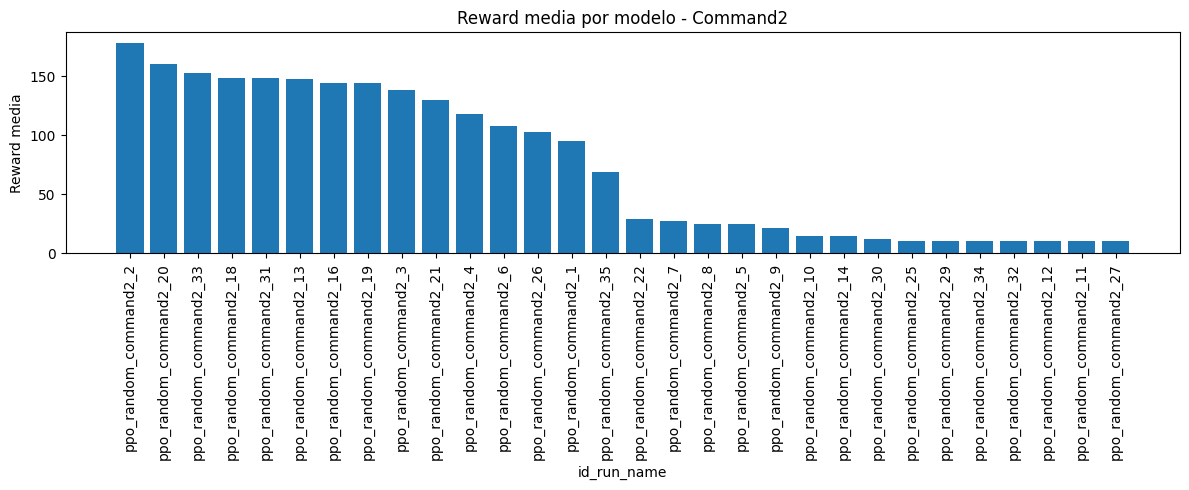

In [8]:
mean_rewards = df_results_grid_actions.groupby(["tarea", "id_run_name"])["reward"].mean()

for tarea, subdf in mean_rewards.groupby(level="tarea"):
    plt.figure(figsize=(12,5))
    
    # Convertir a DataFrame y resetear index para graficar
    plot_df = subdf.reset_index()
    plot_df = plot_df.sort_values("reward", ascending=False)
    
    plt.bar(plot_df["id_run_name"], plot_df["reward"])
    plt.title(f"Reward media por modelo - {tarea}")
    plt.xlabel("id_run_name")
    plt.ylabel("Reward media")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


In [9]:
df_callbacks = pd.read_csv(path_resultados+"/reward_best_models.csv",index_col='id_run_name')
top5_models = df_callbacks.nlargest(5,columns="reward")
top5_models

,iteration,reward,max_reward,std_reward,num_envs_train
id_run_name,,,,,
ppo_random_command2_2,1939,236.263732,264.850739,15.473776,8196
ppo_random_command2_21,713,213.627924,264.552155,23.320007,4096
ppo_random_command2_20,792,200.199774,262.236786,22.301796,1024
ppo_random_command2_3,1773,194.033380,265.639984,18.533038,2048
ppo_random_command2_31,1943,193.693843,252.300720,15.005366,512


Graficamos cómo fue el entrenamiento para los 5 mejores modelos según los callbacks:

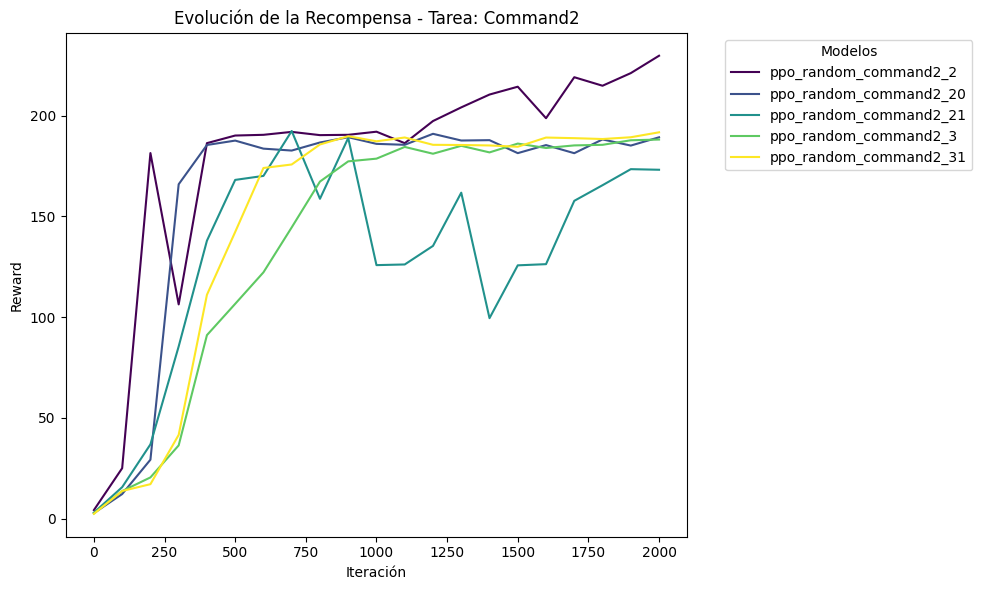

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Aseguramos que `top5_auc` tenga 'tarea' e 'id_run_name' como columnas, no solo en el índice
df_callbacks = pd.read_csv(path_resultados+"/reward_best_models.csv",index_col='id_run_name')
top5_models = df_callbacks.nlargest(5,columns="reward")
top5_reset = top5_models.reset_index()
top5_reset["tarea"] = top5_reset["id_run_name"].apply(get_group)


# Convertir el índice jerárquico en columnas (para acceder a 'tarea' y 'id_run_name')
df_copy_reset = df_copy.reset_index()

# Unimos `top5_auc_reset` con `df_copy_reset` en las columnas comunes: 'tarea' y 'id_run_name'
merged_df = pd.merge(df_copy_reset, top5_reset[['tarea', 'id_run_name']], on=['tarea', 'id_run_name'], how='inner')

# Usamos una lista de colores para asignar un color diferente a cada modelo
colors = plt.cm.viridis(np.linspace(0, 1, len(merged_df['id_run_name'].unique())))

# Ahora, procedemos a graficar
for tarea, task_df in merged_df.groupby('tarea'):
    plt.figure(figsize=(10, 6))
    
    # Iteramos sobre los modelos (id_run_name) para esta tarea
    for i, (run_name, subdf) in enumerate(task_df.groupby('id_run_name')):
        # Graficamos la evolución de la recompensa a lo largo de las iteraciones
        plt.plot(subdf['iteration'], subdf['reward'], label=run_name, color=colors[i])
    
    plt.xlabel('Iteración')
    plt.ylabel('Reward')
    plt.title(f'Evolución de la Recompensa - Tarea: {tarea}')
    plt.legend(title="Modelos", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()



``Cojo los 5 modelos mejores de todos de los callbacks``

In [11]:
import os
df_callbacks = pd.read_csv(path_resultados+"/reward_best_models.csv",index_col='id_run_name')
top5_models = df_callbacks.nlargest(5,columns="reward")
# cojo las direcciones de sus checkpoints
checkpoints = []

powershell_script_test = os.path.join(cfg_dir, "run_tests.ps1")


with open(powershell_script_test, "w") as f:
    f.write("$ErrorActionPreference = 'Stop'\n\n")
    
    for run_id, row in top5_models.iterrows():
        # Extraemos el número del id (ej: de 'ppo_random_hover_4' sacamos '4')
        experiment_number = run_id.split('_')[-1]
        
        # Construimos la ruta exacta del checkpoint
        # Nota: Asegúrate de que path_resultados termine en / o usar os.path.join
        checkpoint_path = f"{path_resultados}/best_model_{run_id}_{int(row['num_envs_train'])}.pt"
        
        f.write(f'Write-Host "Ejecutando Test para Experimento {experiment_number}..."\n')
        
        # Usamos el experiment_number extraído para la tarea (--task)
        # Se añaden flags típicos de play.py: --num_envs 1 y se quita --headless para ver el visualizador
        f.write(f'& "{isaaclab_bat}" -p "{play_script}" '
                f'--task {id_task}-{experiment_number} '
                f'--num_envs 1 '
                f' --headless '
                f'--checkpoint "{checkpoint_path}"\n\n')

print(f"Script de test generado en: {powershell_script_test}")


Script de test generado en: C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/aerotaxi/env_command/env_6/grid_hiperparametros/cfg_files\run_tests.ps1


### Test con 1 entorno

In [12]:
# Ejecuta el entrenamiento de forma automática
# !powershell -ExecutionPolicy Bypass -File "{powershell_script}"
import subprocess
import sys

# Ruta al script que generaste
powershell_script_path = powershell_script_test 

print(f"Iniciando ejecución de: {powershell_script_path}\n")

# Ejecutamos el proceso capturando la salida en tiempo real
process = subprocess.Popen(
    ["powershell.exe", "-ExecutionPolicy", "Bypass", "-File", powershell_script_path],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT, # Redirigimos errores a la salida estándar para verlos
    text=True,
    bufsize=1
)

# Leemos la salida línea a línea conforme se genera
try:
    for line in process.stdout:
        print(line, end="") # Imprime la salida de PowerShell en la celda
        sys.stdout.flush()   # Fuerza a Jupyter a mostrar la línea inmediatamente
except KeyboardInterrupt:
    process.kill()
    print("\nEntrenamiento cancelado por el usuario.")

process.wait()
print("\n--- Todos los experimentos de test han finalizado ---")

Iniciando ejecución de: C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/aerotaxi/env_command/env_6/grid_hiperparametros/cfg_files\run_tests.ps1

Ejecutando Test para Experimento 2...
[INFO] Using python from: C:\Users\Teresa\miniconda3\envs\env_isaaclab\python.exe
[INFO][AppLauncher]: Using device: cuda:0
[INFO][AppLauncher]: Loading experience file: C:\Users\Teresa\miniconda3\envs\env_isaaclab\Lib\site-packages\isaaclab\apps\isaaclab.python.headless.kit
Loading user config located at: 'c:/users/teresa/miniconda3/envs/env_isaaclab/lib/site-packages/isaacsim/kit/data/Kit/Isaac-Sim/5.1/user.config.json'
[Info] [carb] Logging to file: c:/users/teresa/miniconda3/envs/env_isaaclab/lib/site-packages/isaacsim/kit/logs/Kit/Isaac-Sim/5.1/kit_20260105_113155.log
2026-01-05T10:31:55Z s] [Warning] [omni.usd_config.extension] Enable omni.materialx.libs extension to use MaterialX
2026-01-05T10:31:56Z [1,036ms] [Warning] [carb] Acquiring non optional plugin interface which is not listed as dependen

In [13]:
df_callbacks = pd.read_csv(path_resultados+"/reward_best_models.csv",index_col='id_run_name')
top5_models = df_callbacks.nlargest(5,columns="reward")

In [14]:
df_rewards_play = pd.read_csv(path_resultados+'/rewards_play_PPO.csv')

### Test con 64 entornos

In [15]:
import os
df_callbacks = pd.read_csv(path_resultados+"/reward_best_models.csv",index_col='id_run_name')
top5_models = df_callbacks.nlargest(5,columns="reward")
# cojo las direcciones de sus checkpoints
checkpoints = []

powershell_script_test_2 = os.path.join(cfg_dir, "run_tests_2.ps1")

with open(powershell_script_test_2, "w") as f:
    f.write("$ErrorActionPreference = 'Stop'\n\n")
    
    for run_id, row in top5_models.iterrows():
        # Extraemos el número del id (ej: de 'ppo_random_hover_4' sacamos '4')
        experiment_number = run_id.split('_')[-1]
        
        # Construimos la ruta exacta del checkpoint
        # Nota: Asegúrate de que path_resultados termine en / o usar os.path.join
        checkpoint_path = f"{path_resultados}/best_model_{run_id}_{int(row['num_envs_train'])}.pt"
        
        f.write(f'Write-Host "Ejecutando Test para Experimento {experiment_number}..."\n')
        
        # Usamos el experiment_number extraído para la tarea (--task)
        # Se añaden flags típicos de play.py: --num_envs 1 y se quita --headless para ver el visualizador
        f.write(f'& "{isaaclab_bat}" -p "{play_script}" '
                f'--task {id_task}-{experiment_number} '
                f'--num_envs 64 '
                f' --headless '
                f'--checkpoint "{checkpoint_path}"\n\n')

print(f"Script de test generado en: {powershell_script_test_2}")


Script de test generado en: C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/aerotaxi/env_command/env_6/grid_hiperparametros/cfg_files\run_tests_2.ps1


In [16]:
# Ejecuta el entrenamiento de forma automática
# !powershell -ExecutionPolicy Bypass -File "{powershell_script}"
import subprocess
import sys

# Ruta al script que generaste
powershell_script_path = powershell_script_test_2 

print(f"Iniciando ejecución de: {powershell_script_path}\n")

# Ejecutamos el proceso capturando la salida en tiempo real
process = subprocess.Popen(
    ["powershell.exe", "-ExecutionPolicy", "Bypass", "-File", powershell_script_path],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT, # Redirigimos errores a la salida estándar para verlos
    text=True,
    bufsize=1
)

# Leemos la salida línea a línea conforme se genera
try:
    for line in process.stdout:
        print(line, end="") # Imprime la salida de PowerShell en la celda
        sys.stdout.flush()   # Fuerza a Jupyter a mostrar la línea inmediatamente
except KeyboardInterrupt:
    process.kill()
    print("\nEntrenamiento cancelado por el usuario.")

process.wait()
print("\n--- Todos los experimentos de test han finalizado ---")

Iniciando ejecución de: C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/aerotaxi/env_command/env_6/grid_hiperparametros/cfg_files\run_tests_2.ps1

Ejecutando Test para Experimento 2...
[INFO] Using python from: C:\Users\Teresa\miniconda3\envs\env_isaaclab\python.exe
[INFO][AppLauncher]: Using device: cuda:0
[INFO][AppLauncher]: Loading experience file: C:\Users\Teresa\miniconda3\envs\env_isaaclab\Lib\site-packages\isaaclab\apps\isaaclab.python.headless.kit
Loading user config located at: 'c:/users/teresa/miniconda3/envs/env_isaaclab/lib/site-packages/isaacsim/kit/data/Kit/Isaac-Sim/5.1/user.config.json'
[Info] [carb] Logging to file: c:/users/teresa/miniconda3/envs/env_isaaclab/lib/site-packages/isaacsim/kit/logs/Kit/Isaac-Sim/5.1/kit_20260105_113523.log
2026-01-05T10:35:24Z s] [Warning] [omni.usd_config.extension] Enable omni.materialx.libs extension to use MaterialX
2026-01-05T10:35:24Z s] [Warning] [carb] Acquiring non optional plugin interface which is not listed as dependency: [

#### Test con 256 entornos

In [17]:
import os
df_callbacks = pd.read_csv(path_resultados+"/reward_best_models.csv",index_col='id_run_name')
top5_models = df_callbacks.nlargest(5,columns="reward")
# cojo las direcciones de sus checkpoints
checkpoints = []

powershell_script_test_3 = os.path.join(cfg_dir, "run_tests_3.ps1")


with open(powershell_script_test_3, "w") as f:
    f.write("$ErrorActionPreference = 'Stop'\n\n")
    
    for run_id, row in top5_models.iterrows():
        # Extraemos el número del id (ej: de 'ppo_random_hover_4' sacamos '4')
        experiment_number = run_id.split('_')[-1]
        
        # Construimos la ruta exacta del checkpoint
        # Nota: Asegúrate de que path_resultados termine en / o usar os.path.join
        checkpoint_path = f"{path_resultados}/best_model_{run_id}_{int(row['num_envs_train'])}.pt"
        
        f.write(f'Write-Host "Ejecutando Test para Experimento {experiment_number}..."\n')
        
        # Usamos el experiment_number extraído para la tarea (--task)
        # Se añaden flags típicos de play.py: --num_envs 1 y se quita --headless para ver el visualizador
        f.write(f'& "{isaaclab_bat}" -p "{play_script}" '
                f'--task {id_task}-{experiment_number} '
                f'--num_envs 256 '
                f' --headless '
                f'--checkpoint "{checkpoint_path}"\n\n')

print(f"Script de test generado en: {powershell_script_test_3}")


Script de test generado en: C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/aerotaxi/env_command/env_6/grid_hiperparametros/cfg_files\run_tests_3.ps1


In [18]:
# Ejecuta el entrenamiento de forma automática
# !powershell -ExecutionPolicy Bypass -File "{powershell_script}"
import subprocess
import sys

# Ruta al script que generaste
powershell_script_path = powershell_script_test_3 

print(f"Iniciando ejecución de: {powershell_script_path}\n")

# Ejecutamos el proceso capturando la salida en tiempo real
process = subprocess.Popen(
    ["powershell.exe", "-ExecutionPolicy", "Bypass", "-File", powershell_script_path],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT, # Redirigimos errores a la salida estándar para verlos
    text=True,
    bufsize=1
)

# Leemos la salida línea a línea conforme se genera
try:
    for line in process.stdout:
        print(line, end="") # Imprime la salida de PowerShell en la celda
        sys.stdout.flush()   # Fuerza a Jupyter a mostrar la línea inmediatamente
except KeyboardInterrupt:
    process.kill()
    print("\nEntrenamiento cancelado por el usuario.")

process.wait()
print("\n--- Todos los experimentos de test han finalizado ---")

Iniciando ejecución de: C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/aerotaxi/env_command/env_6/grid_hiperparametros/cfg_files\run_tests_3.ps1

Ejecutando Test para Experimento 2...
[INFO] Using python from: C:\Users\Teresa\miniconda3\envs\env_isaaclab\python.exe
[INFO][AppLauncher]: Using device: cuda:0
[INFO][AppLauncher]: Loading experience file: C:\Users\Teresa\miniconda3\envs\env_isaaclab\Lib\site-packages\isaaclab\apps\isaaclab.python.headless.kit
Loading user config located at: 'c:/users/teresa/miniconda3/envs/env_isaaclab/lib/site-packages/isaacsim/kit/data/Kit/Isaac-Sim/5.1/user.config.json'
[Info] [carb] Logging to file: c:/users/teresa/miniconda3/envs/env_isaaclab/lib/site-packages/isaacsim/kit/logs/Kit/Isaac-Sim/5.1/kit_20260105_113900.log
2026-01-05T10:39:00Z s] [Warning] [omni.usd_config.extension] Enable omni.materialx.libs extension to use MaterialX
2026-01-05T10:39:01Z s] [Warning] [carb] Acquiring non optional plugin interface which is not listed as dependency: [

In [19]:
import pandas as pd

df_train = top5_models.copy()
if df_train.index.name == 'id_run_name':
    df_train = df_train.reset_index()

df_train = df_train.rename(columns={
    'reward': 'reward_train',
    'max_reward': 'max_reward_train',
    'std_reward': 'std_train'
})

df_test = df_rewards_play.copy()

df_test = pd.read_csv(path_resultados+'/rewards_play_PPO.csv')
df_test = df_test.rename(columns={
    'reward': 'reward_test',
    'max_reward': 'max_reward_test',
    'std': 'std_test'
})

df_final = pd.merge(
    df_train[['id_run_name', 'num_envs_train', 'reward_train', 'max_reward_train', 'std_train', 'iteration']], 
    df_test[['id_run_name', 'num_envs_test', 'reward_test', 'max_reward_test', 'std_test', 'checkpoint']], 
    on='id_run_name', 
    how='inner'
)

column_order = [
    'id_run_name',
    'num_envs_train',
    'num_envs_test',
    'reward_train', 'reward_test', 
    'max_reward_train', 'max_reward_test', 
    'std_train', 'std_test',
    'iteration'
]
df_final = df_final[column_order]

df_final = df_final.sort_values(by='id_run_name', ascending=False)

In [20]:
df_rewards_play = df_final.sort_values(by="id_run_name",ascending=False)
df_rewards_play = df_rewards_play.reset_index().drop(columns='index')

df_final = df_rewards_play.copy()

df_final['diff_rw_test_train'] = df_final['reward_test'] - df_final['reward_train']

df_final['diferencia(%)'] = (df_final['diff_rw_test_train'] / df_final['reward_train'].abs()) * 100

df_final['diferencia(%)'] = df_final['diferencia(%)'].apply(lambda x: f"{x:+.2f}%")

df_final

,id_run_name,num_envs_train,num_envs_test,reward_train,reward_test,max_reward_train,max_reward_test,std_train,std_test,iteration,diff_rw_test_train,diferencia(%)
0,ppo_random_command2_31,512,1,193.693843,197.020083,252.300720,197.020083,15.005366,0.000000,1943,3.326239,+1.72%
1,ppo_random_command2_31,512,64,193.693843,179.536569,252.300720,255.651795,15.005366,43.588065,1943,-14.157274,-7.31%
2,ppo_random_command2_31,512,256,193.693843,178.644596,252.300720,279.898470,15.005366,42.273708,1943,-15.049247,-7.77%
3,ppo_random_command2_3,2048,1,194.033380,182.332442,265.639984,182.332442,18.533038,0.000000,1773,-11.700938,-6.03%
4,ppo_random_command2_3,2048,64,194.033380,184.921680,265.639984,228.755361,18.533038,27.032410,1773,-9.111700,-4.70%
5,ppo_random_command2_3,2048,256,194.033380,178.776114,265.639984,244.844959,18.533038,32.554005,1773,-15.257266,-7.86%
6,ppo_random_command2_21,4096,1,213.627924,239.496308,264.552155,239.496308,23.320007,0.000000,713,25.868384,+12.11%
7,ppo_random_command2_21,4096,64,213.627924,200.715134,264.552155,282.046678,23.320007,44.027568,713,-12.912790,-6.04%
8,ppo_random_command2_21,4096,256,213.627924,198.001761,264.552155,279.289031,23.320007,40.994552,713,-15.626164,-7.31%
9,ppo_random_command2_20,1024,1,200.199774,182.765525,262.236786,182.765525,22.301796,0.000000,792,-17.434248,-8.71%


Pruebas con un solo entorno: Vemos cómo se comporta la política para un único agente en una prueba aleatoria.

In [21]:
df_final[df_final['num_envs_test'] == 1].sort_values(by='reward_test',ascending=False)

,id_run_name,num_envs_train,num_envs_test,reward_train,reward_test,max_reward_train,max_reward_test,std_train,std_test,iteration,diff_rw_test_train,diferencia(%)
6,ppo_random_command2_21,4096,1,213.627924,239.496308,264.552155,239.496308,23.320007,0.0,713,25.868384,+12.11%
0,ppo_random_command2_31,512,1,193.693843,197.020083,252.300720,197.020083,15.005366,0.0,1943,3.326239,+1.72%
9,ppo_random_command2_20,1024,1,200.199774,182.765525,262.236786,182.765525,22.301796,0.0,792,-17.434248,-8.71%
3,ppo_random_command2_3,2048,1,194.033380,182.332442,265.639984,182.332442,18.533038,0.0,1773,-11.700938,-6.03%
12,ppo_random_command2_2,8196,1,236.263732,88.798485,264.850739,88.798485,15.473776,0.0,1939,-147.465247,-62.42%


``Interpretación``: Vemos que el modelo 38 se ha estampado en la prueba aleatoria, así que ese modelo no debería usarse para ninguna transferencia real.

Pruebas con varios entornos: Vemos cómo se comporta la política en múltiples entornos (varias pruebas simuladas en paralelo), teniendo en cuenta cuál es la desviación de cada uno en test, lo que nos permite inferir si la recompensa es estable para todas las pruebas.

In [22]:
df_final[df_final['num_envs_test'] != 1].sort_values(by='std_test',ascending=True).reset_index().drop(columns="index")

,id_run_name,num_envs_train,num_envs_test,reward_train,reward_test,max_reward_train,max_reward_test,std_train,std_test,iteration,diff_rw_test_train,diferencia(%)
0,ppo_random_command2_20,1024,64,200.199774,183.205435,262.236786,221.427775,22.301796,16.942272,792,-16.994339,-8.49%
1,ppo_random_command2_20,1024,256,200.199774,182.216375,262.236786,245.375587,22.301796,23.057750,792,-17.983398,-8.98%
2,ppo_random_command2_3,2048,64,194.033380,184.921680,265.639984,228.755361,18.533038,27.032410,1773,-9.111700,-4.70%
3,ppo_random_command2_3,2048,256,194.033380,178.776114,265.639984,244.844959,18.533038,32.554005,1773,-15.257266,-7.86%
4,ppo_random_command2_21,4096,256,213.627924,198.001761,264.552155,279.289031,23.320007,40.994552,713,-15.626164,-7.31%
5,ppo_random_command2_31,512,256,193.693843,178.644596,252.300720,279.898470,15.005366,42.273708,1943,-15.049247,-7.77%
6,ppo_random_command2_31,512,64,193.693843,179.536569,252.300720,255.651795,15.005366,43.588065,1943,-14.157274,-7.31%
7,ppo_random_command2_21,4096,64,213.627924,200.715134,264.552155,282.046678,23.320007,44.027568,713,-12.912790,-6.04%
8,ppo_random_command2_2,8196,64,236.263732,201.381234,264.850739,253.893693,15.473776,58.226253,1939,-34.882498,-14.76%
9,ppo_random_command2_2,8196,256,236.263732,196.651157,264.850739,254.257259,15.473776,67.270794,1939,-39.612575,-16.77%


### ``Interpretación de la prueba con 1 entorno``
Si observamos la tabla de la prueba aleatoria con 1 entorno, vemos que el modelo 2 no consigue un buen resultado, y probablemente no haga ni hover ni alcance el punto deseado (hover correctamente son cerca de 120 puntos). Por otro lado, el modelo 21 y el 31 mejoran ligeramente en test con respecto al train, y el 20 y el 3 empeoran ligeramente, pero continúan siendo estables. En esta prueba aleatoria, podemos afirmar que el modelo 2 ha fallado, y por tanto, no es estable.  

### ``Interpretación de las pruebas con n entornos: robustez``
Si observamos la tabla de las pruebas con varios entornos, vemos que los modelos más estables, es decir, que presentan menor variabilidad en las recompensas con respecto a la obtenida en train, son el 20 (16.94 y 23.05 de std en test) y el 3 (27.03 y 32.55 de std en test). Sin embargo, el 2 vemos que es muy inestable (obtiene 58.22 y 67.27), aunque es precisamente este el modelo que mayor recompensa obtiene en test, pero no es un modelo estable. Sin embargo, el modelo 21 vemos que obtiene una buena recompensa, pero presenta un std elevado. 